# Putting the weighting in the solver, not in the data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FiRMLAB-Pisa/torchsolve/blob/main/examples/02-preconditioning.ipynb)

A non-Cartesian acquisition samples the middle of k-space far more densely
than the edge, so its normal operator is badly scaled and conjugate gradient
crawls. The usual fix is to weight the data by the sampling density, which
speeds the solve by changing the problem: the answer is no longer the
least-squares one.

A preconditioner buys the same conditioning without that. It changes the path
the iteration takes and leaves the fixed point where it was, so the answer is
still the least-squares one.

In [1]:
try:
    import torchsolve  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "torchsolve", "matplotlib"],
        check=True,
    )

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

from torchsolve import conjugate_gradient

SIZE = 512


def badly_scaled_system(size=SIZE):
    """An operator whose scale spans three decades, as sampling density does.

    Coupled rather than diagonal, so that the Jacobi preconditioner below is an
    approximation of the inverse rather than the inverse itself. A diagonal
    operator would be solved exactly in one preconditioned step and would show
    nothing.
    """
    generator = torch.Generator().manual_seed(0)
    density = torch.logspace(0, 3, size, dtype=torch.float64)
    coupling = torch.randn(size, size, generator=generator, dtype=torch.float64)
    coupling = 0.35 * (coupling + coupling.T) / size**0.5
    matrix = torch.diag(density) + coupling * density.sqrt().outer(density.sqrt())
    truth = torch.randn(size, generator=generator, dtype=torch.float64)
    normal = lambda vector: matrix @ vector
    return normal, density, truth, matrix @ truth


normal, density, truth, target = badly_scaled_system()
print(f"the operator's scale spans {density.max() / density.min():.0f}x")

the operator's scale spans 1000x


## What it buys

Solved afresh at each iteration count, so the curve is the error against
effort rather than the residual the solver happens to be tracking.

In [3]:
ITERATIONS = 40
jacobi = lambda vector: vector / density


def residual_history(preconditioner):
    return [
        (
            conjugate_gradient(
                normal, target, max_iter=count, preconditioner=preconditioner
            ).solution
            - truth
        )
        .norm()
        .item()
        / truth.norm().item()
        for count in range(1, ITERATIONS + 1)
    ]


plain = residual_history(None)
shaped = residual_history(jacobi)
print(
    f"after {ITERATIONS} iterations: plain {plain[-1]:.2e}, "
    f"preconditioned {shaped[-1]:.2e}"
)

reached = next(
    (step for step, value in enumerate(shaped, 1) if value < plain[-1]), None
)
print(f"preconditioned passes {ITERATIONS} plain iterations after {reached} of its own")

after 40 iterations: plain 1.94e-01, preconditioned 1.68e-04
preconditioned passes 40 plain iterations after 9 of its own


The operator here is diagonal in its dominant part, which is the cleanest way
to show what the conditioning costs — and on a purely diagonal system dividing
the data by the density is exactly right, so nothing here argues against it.
What the argument rests on is that a real acquisition is overdetermined, where
weighting the data changes which least-squares problem is being solved.

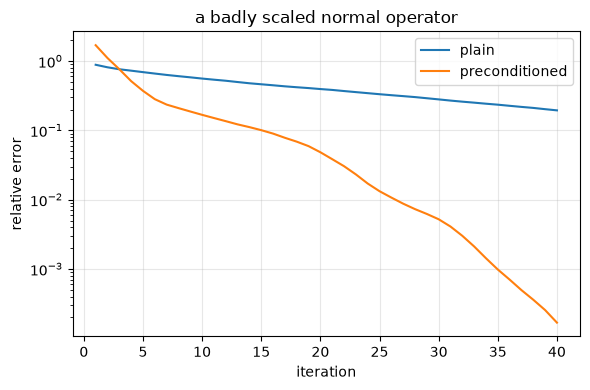

In [4]:
steps = range(1, ITERATIONS + 1)
figure, axis = plt.subplots(figsize=(6, 4))
axis.semilogy(steps, plain, label="plain")
axis.semilogy(steps, shaped, label="preconditioned")
axis.set_xlabel("iteration")
axis.set_ylabel("relative error")
axis.set_title("a badly scaled normal operator")
axis.legend()
axis.grid(alpha=0.3)
figure.tight_layout()

figures = Path("figures")
if figures.is_dir():
    figure.savefig(figures / "preconditioning.png", dpi=120)